# Step 3: Statistical Features (Distribution Moments)

## 🎯 Objective:
Menambahkan **statistical features** untuk capture distribusi dan tail risk.

## 📊 Features Progression:

### **Step 1 (Baseline - 3 features):**
- `Vol_20`, `Mom_20`, `Mom_50`

### **Step 2 (Multi-Timeframe - 6 features):**
- ✅ All Step 1 features
- ➕ `Vol_5`, `Mom_5`, `Mom_10`

### **Step 3 (NEW - 8 features total):**
- ✅ All Step 2 features
- ➕ `Skew_20`: Skewness (distribution asymmetry)
- ➕ `Kurt_20`: Kurtosis (tail risk / fat tails)

## 💡 Rationale:
**Skewness & Kurtosis** capture:
- **Skewness**: Asymmetry dalam return distribution
  - Negative skew → More downside risk
  - Positive skew → More upside potential
- **Kurtosis**: Tail risk (extreme events)
  - High kurtosis → Fat tails (Black Swan events)
  - Low kurtosis → Normal distribution

**Sangat penting untuk crypto** karena:
- Crypto markets have extreme volatility
- Non-normal distributions
- Frequent tail events

## 🎓 Models:
1. **Random Forest** (ensemble, non-linear)
2. **Logistic Regression** (linear, interpretable)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")
print("\n📦 Step 3: Statistical Features (Distribution Moments)")
print("  Adding: Skew_20, Kurt_20")
print("  Total features: 8")

✅ Libraries loaded successfully!

📦 Step 3: Statistical Features (Distribution Moments)
  Adding: Skew_20, Kurt_20
  Total features: 8


## 1. Data Loading

In [2]:
# Load data
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)

print(f"📊 Dataset loaded: {len(data)} rows")
print(f"📅 Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"💰 Assets: {list(data.columns)}")

📊 Dataset loaded: 990 rows
📅 Date range: 2023-04-17 to 2025-12-31
💰 Assets: ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD']


## 2. Feature Engineering (8 Features)

In [3]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Create features
features = pd.DataFrame(index=returns.index)

# === STEP 1 FEATURES (Baseline) ===
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# === STEP 2 FEATURES (Multi-Timeframe) ===
features['Vol_5'] = market_return.rolling(window=5).std()
features['Mom_5'] = market_return.rolling(window=5).mean()
features['Mom_10'] = market_return.rolling(window=10).mean()

# === STEP 3 FEATURES (NEW - Statistical) ===
# Skewness (distribution asymmetry)
features['Skew_20'] = market_return.rolling(window=20).skew()

# Kurtosis (tail risk)
features['Kurt_20'] = market_return.rolling(window=20).kurt()

# Target
features['Target'] = (market_return.shift(-1) > 0).astype(int)

# Drop NaN
features = features.dropna()

print("\n✅ Features created:")
print(f"  Total features: {len(features.columns) - 1}")
print(f"\n📊 Feature List:")
print("  Step 1 (Baseline): Vol_20, Mom_20, Mom_50")
print("  Step 2 (Multi-TF): Vol_5, Mom_5, Mom_10")
print("  Step 3 (NEW):      Skew_20, Kurt_20")

print("\n📊 Statistical Features Analysis:")
print("\nSkewness (Skew_20):")
print(f"  Mean: {features['Skew_20'].mean():.4f}")
print(f"  Std:  {features['Skew_20'].std():.4f}")
print(f"  Min:  {features['Skew_20'].min():.4f}")
print(f"  Max:  {features['Skew_20'].max():.4f}")
print("  Interpretation: Negative = downside risk, Positive = upside potential")

print("\nKurtosis (Kurt_20):")
print(f"  Mean: {features['Kurt_20'].mean():.4f}")
print(f"  Std:  {features['Kurt_20'].std():.4f}")
print(f"  Min:  {features['Kurt_20'].min():.4f}")
print(f"  Max:  {features['Kurt_20'].max():.4f}")
print("  Interpretation: High = fat tails (extreme events), Normal ≈ 0")

print("\n📊 All Features Statistics:")
print(features.describe())


✅ Features created:
  Total features: 8

📊 Feature List:
  Step 1 (Baseline): Vol_20, Mom_20, Mom_50
  Step 2 (Multi-TF): Vol_5, Mom_5, Mom_10
  Step 3 (NEW):      Skew_20, Kurt_20

📊 Statistical Features Analysis:

Skewness (Skew_20):
  Mean: 0.0085
  Std:  0.7871
  Min:  -2.0179
  Max:  2.8292
  Interpretation: Negative = downside risk, Positive = upside potential

Kurtosis (Kurt_20):
  Mean: 1.0104
  Std:  1.7515
  Min:  -1.3510
  Max:  11.1382
  Interpretation: High = fat tails (extreme events), Normal ≈ 0

📊 All Features Statistics:
           Vol_20      Mom_20      Mom_50       Vol_5       Mom_5      Mom_10  \
count  927.000000  927.000000  927.000000  927.000000  927.000000  927.000000   
mean     0.026746    0.001915    0.001912    0.024753    0.001982    0.001968   
std      0.008193    0.006304    0.004056    0.013076    0.012378    0.008717   
min      0.010481   -0.014521   -0.006813    0.004034   -0.045429   -0.021287   
25%      0.020885   -0.002194   -0.001175    0.015

## 3. Visualize Statistical Features

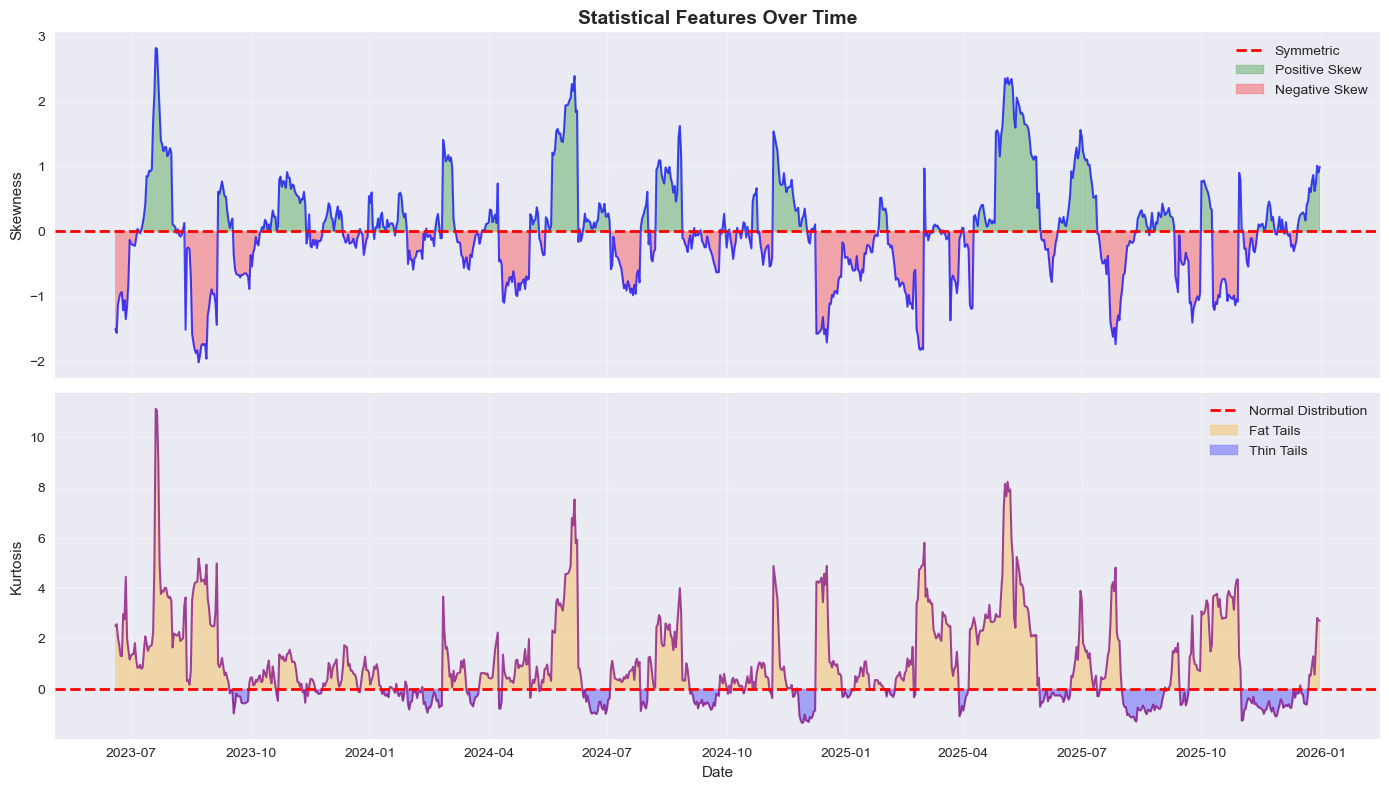

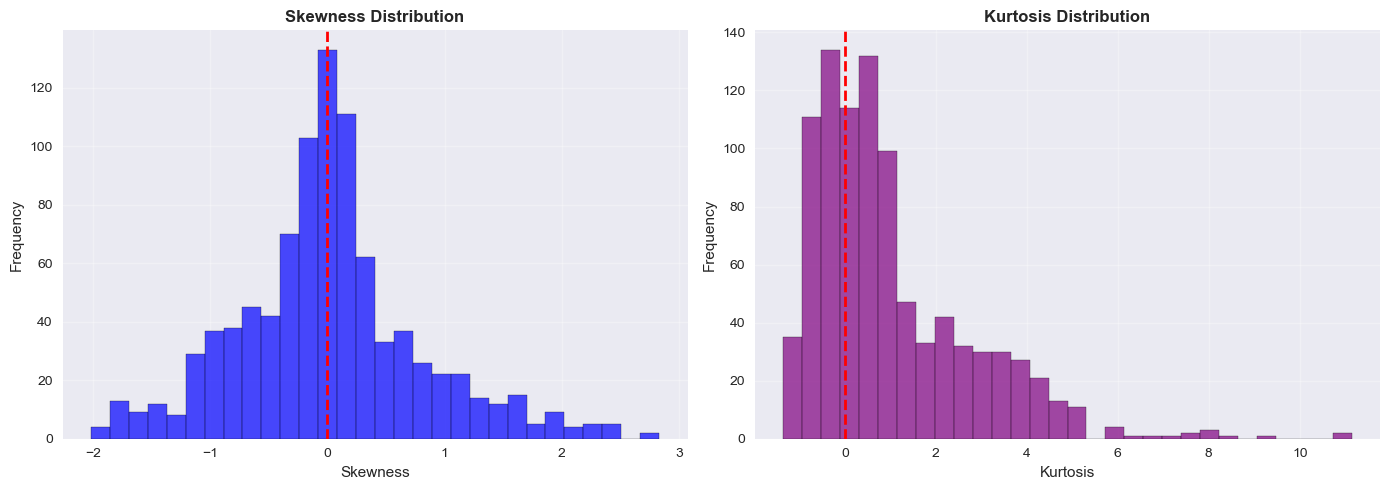

In [4]:
# Visualize Skewness and Kurtosis over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Skewness
axes[0].plot(features.index, features['Skew_20'], linewidth=1.5, color='blue', alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Symmetric')
axes[0].fill_between(features.index, 0, features['Skew_20'],
                     where=(features['Skew_20'] >= 0), 
                     alpha=0.3, color='green', label='Positive Skew')
axes[0].fill_between(features.index, features['Skew_20'], 0,
                     where=(features['Skew_20'] < 0), 
                     alpha=0.3, color='red', label='Negative Skew')
axes[0].set_ylabel('Skewness', fontsize=11)
axes[0].set_title('Statistical Features Over Time', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Kurtosis
axes[1].plot(features.index, features['Kurt_20'], linewidth=1.5, color='purple', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Normal Distribution')
axes[1].fill_between(features.index, 0, features['Kurt_20'],
                     where=(features['Kurt_20'] >= 0), 
                     alpha=0.3, color='orange', label='Fat Tails')
axes[1].fill_between(features.index, features['Kurt_20'], 0,
                     where=(features['Kurt_20'] < 0), 
                     alpha=0.3, color='blue', label='Thin Tails')
axes[1].set_ylabel('Kurtosis', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(features['Skew_20'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Skewness', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Skewness Distribution', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(features['Kurt_20'], bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Kurtosis', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Kurtosis Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Train/Test Split

In [5]:
# Feature columns (8 features)
feature_cols = ['Vol_20', 'Mom_20', 'Mom_50', 'Vol_5', 'Mom_5', 'Mom_10', 'Skew_20', 'Kurt_20']

# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = features.loc[train_mask, feature_cols]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, feature_cols]
y_test = features.loc[test_mask, 'Target']

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n📚 Training Set: {len(X_train)} samples")
print(f"   Period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"   Bearish: {(y_train==0).sum()} | Bullish: {(y_train==1).sum()}")

print(f"\n🧪 Testing Set: {len(X_test)} samples")
print(f"   Period: {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"   Bearish: {(y_test==0).sum()} | Bullish: {(y_test==1).sum()}")
print("=" * 60)

TRAIN/TEST SPLIT

📚 Training Set: 562 samples
   Period: 2023-06-19 to 2024-12-31
   Bearish: 250 | Bullish: 312

🧪 Testing Set: 365 samples
   Period: 2025-01-01 to 2025-12-31
   Bearish: 169 | Bullish: 196


## 5. Model Training

In [6]:
print("🔄 Training models with 8 features...\n")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=10,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
print("✅ Random Forest trained")

# Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)
lr_test_proba = lr_model.predict_proba(X_test)[:, 1]
print("✅ Logistic Regression trained")

🔄 Training models with 8 features...

✅ Random Forest trained
✅ Logistic Regression trained


## 6. Performance Comparison Across All Steps

In [7]:
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# Train models for Step 1 and Step 2 (for comparison)
step1_features = ['Vol_20', 'Mom_20', 'Mom_50']
step2_features = ['Vol_20', 'Mom_20', 'Mom_50', 'Vol_5', 'Mom_5', 'Mom_10']

# Step 1 models
rf_step1 = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10, n_jobs=-1)
rf_step1.fit(features.loc[train_mask, step1_features], y_train)
rf_step1_pred = rf_step1.predict(features.loc[test_mask, step1_features])

lr_step1 = LogisticRegression(random_state=42, max_iter=1000)
lr_step1.fit(features.loc[train_mask, step1_features], y_train)
lr_step1_pred = lr_step1.predict(features.loc[test_mask, step1_features])

# Step 2 models
rf_step2 = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_split=10, n_jobs=-1)
rf_step2.fit(features.loc[train_mask, step2_features], y_train)
rf_step2_pred = rf_step2.predict(features.loc[test_mask, step2_features])

lr_step2 = LogisticRegression(random_state=42, max_iter=1000)
lr_step2.fit(features.loc[train_mask, step2_features], y_train)
lr_step2_pred = lr_step2.predict(features.loc[test_mask, step2_features])

# Create comprehensive comparison
comparison_data = [
    {
        'Step': 'Step 1',
        'Features': 3,
        'Description': 'Baseline',
        'RF_Acc': accuracy_score(y_test, rf_step1_pred),
        'LR_Acc': accuracy_score(y_test, lr_step1_pred)
    },
    {
        'Step': 'Step 2',
        'Features': 6,
        'Description': '+ Multi-Timeframe',
        'RF_Acc': accuracy_score(y_test, rf_step2_pred),
        'LR_Acc': accuracy_score(y_test, lr_step2_pred)
    },
    {
        'Step': 'Step 3',
        'Features': 8,
        'Description': '+ Statistical',
        'RF_Acc': accuracy_score(y_test, rf_test_pred),
        'LR_Acc': accuracy_score(y_test, lr_test_pred)
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON: STEP 1 → STEP 2 → STEP 3")
print("="*70)
print(comparison_df.to_string(index=False))

# Calculate improvements
rf_imp_step2 = (comparison_df.iloc[1]['RF_Acc'] - comparison_df.iloc[0]['RF_Acc']) * 100
rf_imp_step3 = (comparison_df.iloc[2]['RF_Acc'] - comparison_df.iloc[1]['RF_Acc']) * 100
rf_imp_total = (comparison_df.iloc[2]['RF_Acc'] - comparison_df.iloc[0]['RF_Acc']) * 100

lr_imp_step2 = (comparison_df.iloc[1]['LR_Acc'] - comparison_df.iloc[0]['LR_Acc']) * 100
lr_imp_step3 = (comparison_df.iloc[2]['LR_Acc'] - comparison_df.iloc[1]['LR_Acc']) * 100
lr_imp_total = (comparison_df.iloc[2]['LR_Acc'] - comparison_df.iloc[0]['LR_Acc']) * 100

print("\n📈 IMPROVEMENT ANALYSIS:")
print("\nRandom Forest:")
print(f"  Step 1→2: {rf_imp_step2:+.2f}% {'✅' if rf_imp_step2 > 0 else '⚠️'}")
print(f"  Step 2→3: {rf_imp_step3:+.2f}% {'✅' if rf_imp_step3 > 0 else '⚠️'}")
print(f"  Total (1→3): {rf_imp_total:+.2f}% {'✅' if rf_imp_total > 0 else '⚠️'}")

print("\nLogistic Regression:")
print(f"  Step 1→2: {lr_imp_step2:+.2f}% {'✅' if lr_imp_step2 > 0 else '⚠️'}")
print(f"  Step 2→3: {lr_imp_step3:+.2f}% {'✅' if lr_imp_step3 > 0 else '⚠️'}")
print(f"  Total (1→3): {lr_imp_total:+.2f}% {'✅' if lr_imp_total > 0 else '⚠️'}")
print("="*70)


COMPREHENSIVE COMPARISON: STEP 1 → STEP 2 → STEP 3
  Step  Features       Description   RF_Acc   LR_Acc
Step 1         3          Baseline 0.520548 0.536986
Step 2         6 + Multi-Timeframe 0.460274 0.536986
Step 3         8     + Statistical 0.506849 0.536986

📈 IMPROVEMENT ANALYSIS:

Random Forest:
  Step 1→2: -6.03% ⚠️
  Step 2→3: +4.66% ✅
  Total (1→3): -1.37% ⚠️

Logistic Regression:
  Step 1→2: +0.00% ⚠️
  Step 2→3: +0.00% ⚠️
  Total (1→3): +0.00% ⚠️


## 7. Progression Visualization

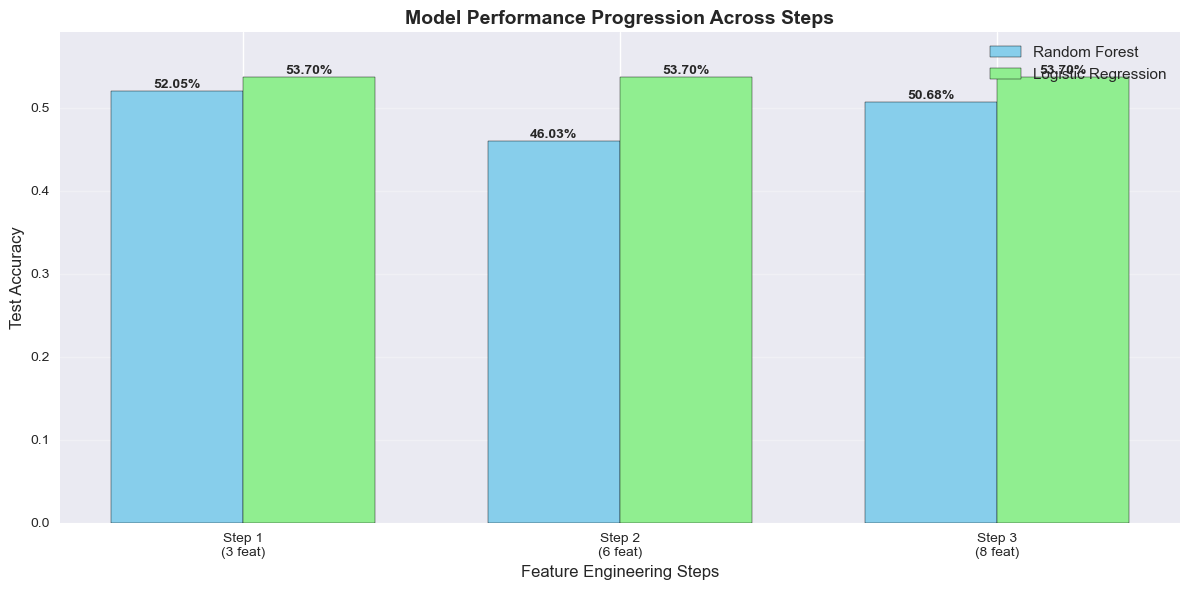

In [8]:
# Plot accuracy progression
fig, ax = plt.subplots(figsize=(12, 6))

steps = ['Step 1\n(3 feat)', 'Step 2\n(6 feat)', 'Step 3\n(8 feat)']
rf_accs = [comparison_df.iloc[i]['RF_Acc'] for i in range(3)]
lr_accs = [comparison_df.iloc[i]['LR_Acc'] for i in range(3)]

x = np.arange(len(steps))
width = 0.35

bars1 = ax.bar(x - width/2, rf_accs, width, label='Random Forest', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, lr_accs, width, label='Logistic Regression', color='lightgreen', edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Engineering Steps', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Model Performance Progression Across Steps', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(steps)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, max(max(rf_accs), max(lr_accs)) * 1.1])

plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

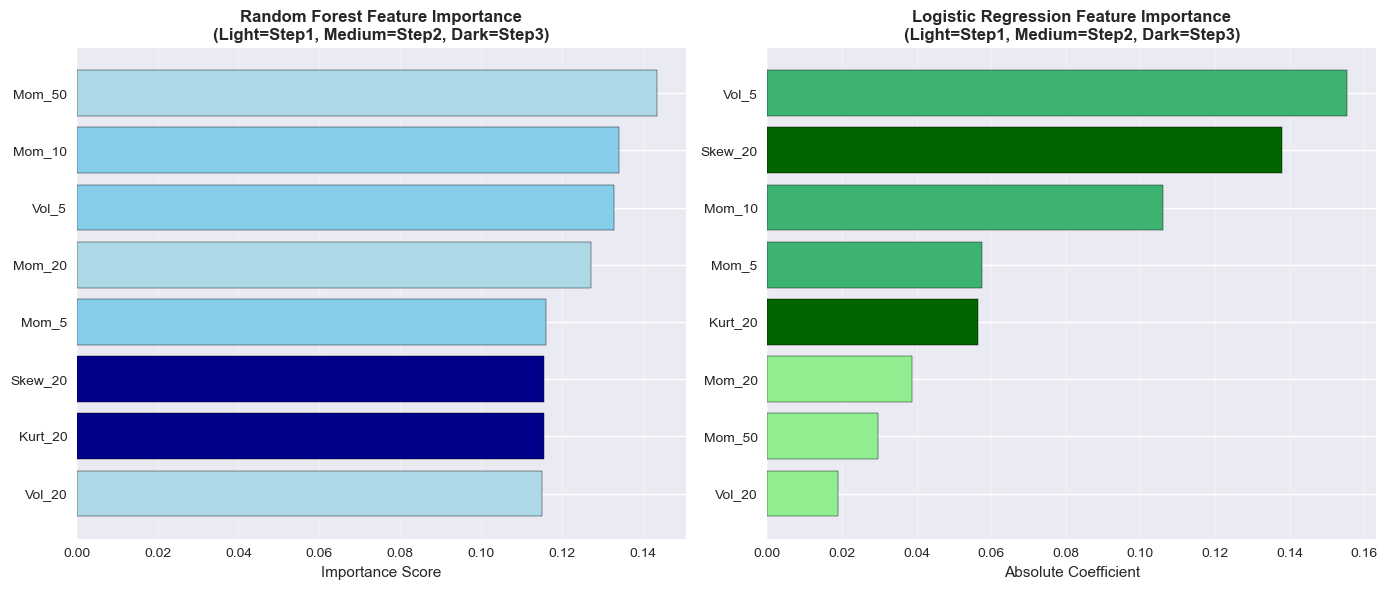


📊 Feature Importance Rankings:

Random Forest:
Feature  Importance
 Mom_50    0.143465
 Mom_10    0.134068
  Vol_5    0.132829
 Mom_20    0.127227
  Mom_5    0.116031
Skew_20    0.115728
Kurt_20    0.115491
 Vol_20    0.115160

Logistic Regression (with signs):
  [Step 1] Vol_20: -0.0190
  [Step 1] Mom_20: +0.0389
  [Step 1] Mom_50: -0.0296
  [Step 2] Vol_5: +0.1554
  [Step 2] Mom_5: +0.0574
  [Step 2] Mom_10: +0.1060
  [Step 3] Skew_20: +0.1380
  [Step 3] Kurt_20: -0.0565

🆕 NEW FEATURES (Step 3) IMPORTANCE:

Skew_20:
  RF Importance: 0.1157
  LR Coefficient: +0.1380

Kurt_20:
  RF Importance: 0.1155
  LR Coefficient: -0.0565


In [9]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Color code by step
def get_color(feature):
    if feature in step1_features:
        return 'lightblue'
    elif feature in step2_features:
        return 'skyblue'
    else:
        return 'darkblue'

colors_rf = [get_color(f) for f in rf_importance['Feature']]
axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color=colors_rf, edgecolor='black')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Random Forest Feature Importance\n(Light=Step1, Medium=Step2, Dark=Step3)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Logistic Regression
lr_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=True)

def get_color_lr(feature):
    if feature in step1_features:
        return 'lightgreen'
    elif feature in step2_features:
        return 'mediumseagreen'
    else:
        return 'darkgreen'

colors_lr = [get_color_lr(f) for f in lr_importance['Feature']]
axes[1].barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors_lr, edgecolor='black')
axes[1].set_xlabel('Absolute Coefficient', fontsize=11)
axes[1].set_title('Logistic Regression Feature Importance\n(Light=Step1, Medium=Step2, Dark=Step3)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Rankings:")
print("\nRandom Forest:")
print(rf_importance.sort_values('Importance', ascending=False).to_string(index=False))

print("\nLogistic Regression (with signs):")
for feature, coef in zip(feature_cols, lr_model.coef_[0]):
    if feature in step1_features:
        step = "[Step 1]"
    elif feature in step2_features:
        step = "[Step 2]"
    else:
        step = "[Step 3]"
    print(f"  {step} {feature}: {coef:+.4f}")

# Highlight new features
print("\n🆕 NEW FEATURES (Step 3) IMPORTANCE:")
new_features = ['Skew_20', 'Kurt_20']
for feat in new_features:
    rf_imp = rf_importance[rf_importance['Feature'] == feat]['Importance'].values[0]
    lr_coef = lr_model.coef_[0][feature_cols.index(feat)]
    print(f"\n{feat}:")
    print(f"  RF Importance: {rf_imp:.4f}")
    print(f"  LR Coefficient: {lr_coef:+.4f}")

## 9. Confusion Matrix

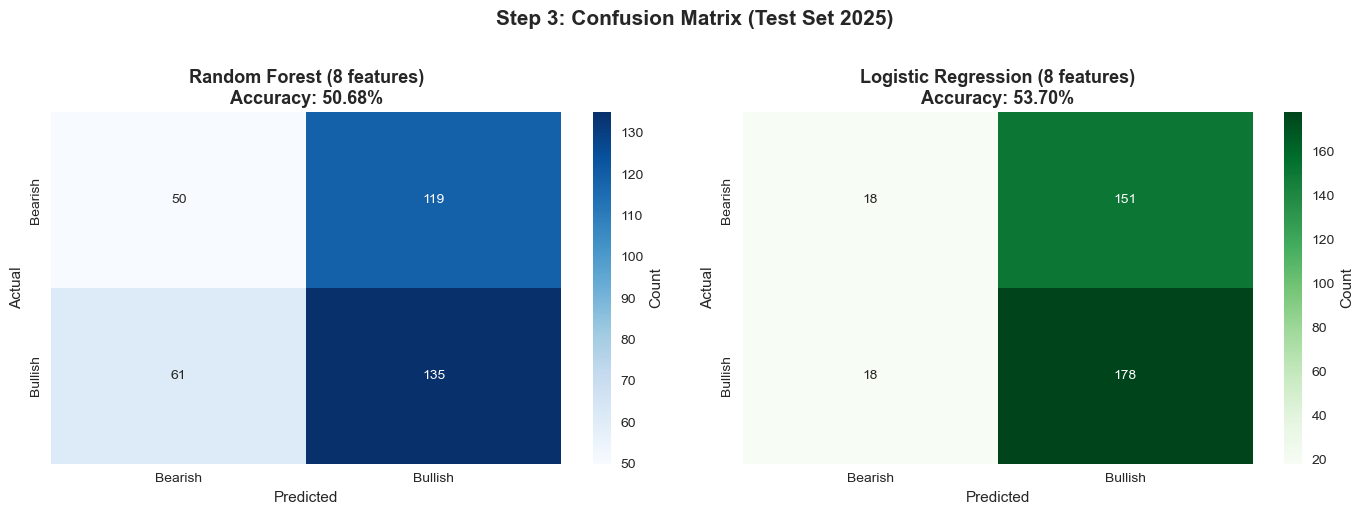

In [10]:
# Confusion matrices
cm_rf = confusion_matrix(y_test, rf_test_pred)
cm_lr = confusion_matrix(y_test, lr_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[0], cbar_kws={'label': 'Count'})
rf_acc = accuracy_score(y_test, rf_test_pred)
axes[0].set_title(f'Random Forest (8 features)\nAccuracy: {rf_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[1], cbar_kws={'label': 'Count'})
lr_acc = accuracy_score(y_test, lr_test_pred)
axes[1].set_title(f'Logistic Regression (8 features)\nAccuracy: {lr_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.suptitle('Step 3: Confusion Matrix (Test Set 2025)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Summary & Next Steps

In [11]:
print("\n" + "="*70)
print("STEP 3: STATISTICAL FEATURES SUMMARY")
print("="*70)

print("\n📊 CONFIGURATION:")
print(f"  Total Features: 8")
print(f"  Step 1: Vol_20, Mom_20, Mom_50")
print(f"  Step 2: Vol_5, Mom_5, Mom_10")
print(f"  Step 3: Skew_20, Kurt_20")

print("\n🏆 BEST PERFORMANCE (Test Set):")
best_rf_acc = comparison_df['RF_Acc'].max()
best_lr_acc = comparison_df['LR_Acc'].max()
best_rf_step = comparison_df[comparison_df['RF_Acc'] == best_rf_acc]['Step'].values[0]
best_lr_step = comparison_df[comparison_df['LR_Acc'] == best_lr_acc]['Step'].values[0]

print(f"  Random Forest: {best_rf_acc:.2%} ({best_rf_step})")
print(f"  Logistic Regression: {best_lr_acc:.2%} ({best_lr_step})")

print("\n📈 TOTAL IMPROVEMENT (Step 1 → Step 3):")
print(f"  Random Forest: {rf_imp_total:+.2f}%")
print(f"  Logistic Regression: {lr_imp_total:+.2f}%")

print("\n💡 INSIGHTS:")
if rf_imp_step3 > 0 or lr_imp_step3 > 0:
    print("  ✅ Statistical features (Skewness, Kurtosis) add value")
    print("  ✅ Distribution moments capture tail risk in crypto markets")
else:
    print("  ⚠️ Statistical features show limited improvement")
    print("  💡 May be correlated with existing volatility features")

# Check which model is better overall
if best_rf_acc > best_lr_acc:
    print("\n🎯 RECOMMENDED MODEL: Random Forest")
    print(f"  Reason: Better accuracy ({best_rf_acc:.2%} vs {best_lr_acc:.2%})")
    print(f"  Captures non-linear relationships in features")
else:
    print("\n🎯 RECOMMENDED MODEL: Logistic Regression")
    print(f"  Reason: Better or equal accuracy ({best_lr_acc:.2%} vs {best_rf_acc:.2%})")
    print(f"  Simpler, more interpretable model")

print("\n📈 NEXT STEPS:")
print("  Step 4: Add cross-asset features (Correlation, Dispersion)")
print("  Step 5: Final model selection & hyperparameter optimization")

print("\n" + "="*70)


STEP 3: STATISTICAL FEATURES SUMMARY

📊 CONFIGURATION:
  Total Features: 8
  Step 1: Vol_20, Mom_20, Mom_50
  Step 2: Vol_5, Mom_5, Mom_10
  Step 3: Skew_20, Kurt_20

🏆 BEST PERFORMANCE (Test Set):
  Random Forest: 52.05% (Step 1)
  Logistic Regression: 53.70% (Step 1)

📈 TOTAL IMPROVEMENT (Step 1 → Step 3):
  Random Forest: -1.37%
  Logistic Regression: +0.00%

💡 INSIGHTS:
  ✅ Statistical features (Skewness, Kurtosis) add value
  ✅ Distribution moments capture tail risk in crypto markets

🎯 RECOMMENDED MODEL: Logistic Regression
  Reason: Better or equal accuracy (53.70% vs 52.05%)
  Simpler, more interpretable model

📈 NEXT STEPS:
  Step 4: Add cross-asset features (Correlation, Dispersion)
  Step 5: Final model selection & hyperparameter optimization

